In [1]:
# %%
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path

In [2]:
# %%
city = "bogota"

gpkg = Path(
    f"/home/fbellisardi/code/topolity/output/terrain_aware_densification/"
    f"{city}/{city}_selected_favorable_unfavorable_cells.gpkg"
)

gdf = gpd.read_file(gpkg)
gdf_ll = gdf.to_crs("EPSG:4326")

gdf_ll.head()

,cell_id,x_min,y_min,x_max,y_max,centroid_x_x,centroid_y_x,population,nearest_node,node_distance,...,scenario_type,rank_total,zone_label,zone_color,selection_ranking_col,horizontal_reference_joules,horizontal_tolerance_used,min_selected_distance_used_m,horizontal_cost_relative_to_ref_pct,geometry
0,89_105,-8.257518e+06,517046.125293,-8.256518e+06,518046.125293,-8.257018e+06,517546.125293,25689.988281,25298,405.792425,...,favorable,1,Favorable 1,#1b9e77,vertical_work_joules,7.093262e+11,0.05,5000.0,1.708655,"POLYGON ((-74.16956 4.63963, -74.16956 4.64858..."
1,93_94,-8.253518e+06,506046.125293,-8.252518e+06,507046.125293,-8.253018e+06,506546.125293,25744.203125,11397,17.529585,...,unfavorable,5,Unfavorable 2,#e7298a,vertical_work_joules,7.093262e+11,0.05,5000.0,4.581052,"POLYGON ((-74.13363 4.54113, -74.13363 4.55008..."
2,98_94,-8.248518e+06,506046.125293,-8.247518e+06,507046.125293,-8.248018e+06,506546.125293,26994.566406,10999,43.486284,...,unfavorable,4,Unfavorable 1,#d95f02,vertical_work_joules,7.093262e+11,0.05,5000.0,-2.861636,"POLYGON ((-74.08871 4.54113, -74.08871 4.55008..."
3,98_117,-8.248518e+06,529046.125293,-8.247518e+06,530046.125293,-8.248018e+06,529546.125293,26955.253906,17136,97.165632,...,favorable,2,Favorable 2,#7570b3,vertical_work_joules,7.093262e+11,0.05,5000.0,-4.768551,"POLYGON ((-74.08871 4.74706, -74.08871 4.75601..."
4,103_116,-8.243518e+06,528046.125293,-8.242518e+06,529046.125293,-8.243018e+06,528546.125293,25514.306641,3612,41.050673,...,favorable,3,Favorable 3,#66a61e,vertical_work_joules,7.093262e+11,0.05,5000.0,-2.874882,"POLYGON ((-74.0438 4.73811, -74.0438 4.74706, ..."


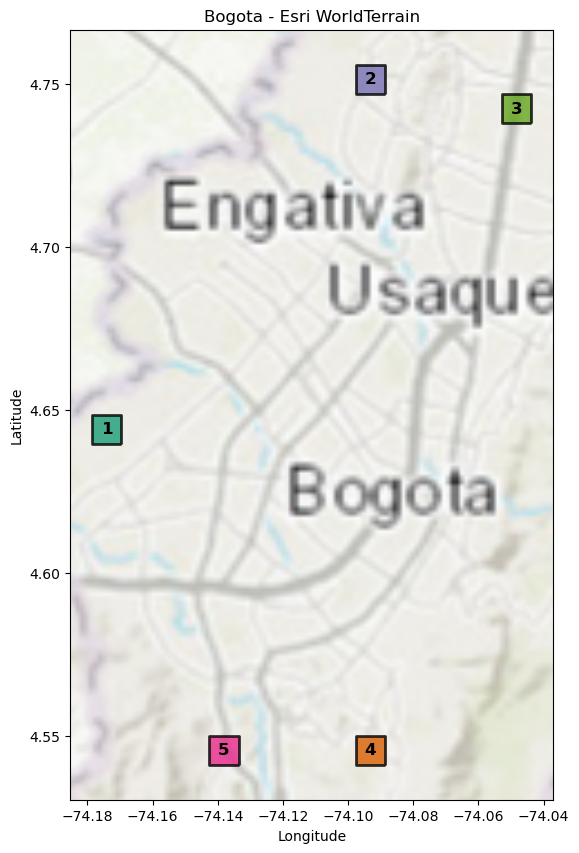

In [3]:
# %%
fig, ax = plt.subplots(figsize=(10, 10))

# plot selected cells
gdf_ll.plot(
    ax=ax,
    color=gdf_ll["zone_color"],
    edgecolor="black",
    linewidth=2,
    alpha=0.8,
    zorder=10,
)

# labels
for _, row in gdf_ll.iterrows():
    c = row.geometry.centroid
    ax.text(
        c.x,
        c.y,
        str(int(row["rank_total"])),
        ha="center",
        va="center",
        fontsize=12,
        weight="bold",
        zorder=20,
    )

# basemap with terrain
ctx.add_basemap(
    ax,
    crs=gdf_ll.crs,
    source=ctx.providers.Esri.WorldTopoMap,
    zoom=10,
    alpha=1,
    attribution=False,
)

ax.set_title(f"{city.title()} - Esri WorldTerrain")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.show()

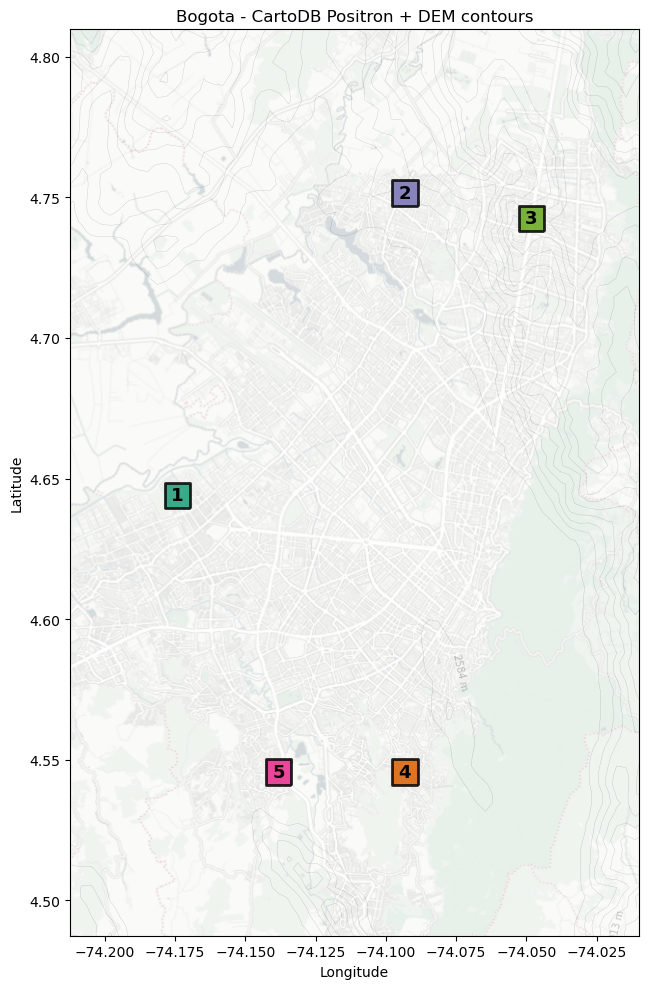

In [10]:
# %%
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LightSource
from rasterio.enums import Resampling

DEM_FILE = f"/home/fbellisardi/code/topolity/data/data_processed/{city}/dem/{city}_dem.tif"

provider = ctx.providers.CartoDB.PositronNoLabels
downsample = 4

with rasterio.open(DEM_FILE) as src:
    dem = src.read(
        1,
        out_shape=(src.height // downsample, src.width // downsample),
        resampling=Resampling.bilinear,
    ).astype("float32")

    bounds = src.bounds
    nodata = src.nodata

if nodata is not None:
    dem[dem == nodata] = np.nan

dem[~np.isfinite(dem)] = np.nan

fig, ax = plt.subplots(figsize=(10, 10))

xmin, ymin, xmax, ymax = gdf_ll.total_bounds
pad_x = (xmax - xmin) * 0.25
pad_y = (ymax - ymin) * 0.25

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

ctx.add_basemap(
    ax,
    crs=gdf_ll.crs,
    source=provider,
    alpha=1,
    attribution=False,
    zorder=1,
)

gdf_ll.plot(
    ax=ax,
    color=gdf_ll["zone_color"],
    edgecolor="black",
    linewidth=2,
    alpha=0.85,
    zorder=20,
)

levels = np.linspace(
    np.nanpercentile(dem, 2),
    np.nanpercentile(dem, 98),
    40,
)

contours = ax.contour(
    dem,
    levels=levels,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
    colors="black",
    linewidths=0.25,
    alpha=0.22,
    zorder=12,
)

ax.clabel(
    contours,
    contours.levels[::5],
    inline=True,
    fontsize=7,
    fmt="%.0f m",
)

for _, row in gdf_ll.iterrows():
    c = row.geometry.centroid
    ax.text(
        c.x,
        c.y,
        str(int(row["rank_total"])),
        ha="center",
        va="center",
        fontsize=13,
        weight="bold",
        color="black",
        zorder=30,
    )

ax.set_title(f"{city.title()} - CartoDB Positron + DEM contours")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()